In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scp
from scipy.signal import find_peaks
from sklearn.mixture import GaussianMixture,BayesianGaussianMixture

In [10]:
#Conversions
boundary_  = lambda p:p.view(np.uint32) >> 16    
flag_      = lambda p:p.view(np.uint32) & 0xffff

identity_ = lambda p:p.view(np.uint32)[3,1]   
primIdx_   = lambda p:identity_(p) >> 16  
instanceId_  = lambda p:identity_(p) & 0xffff  

idx_      = lambda p:p.view(np.uint32)[3,2] & 0x7fffffff
orient_   = lambda p:p.view(np.uint32)[3,2] >> 31

flagmask_ = lambda p:p.view(np.uint32)


In [11]:
## Root 

In [12]:
import h5py


In [13]:
def GetInfoH5(filePath):
    All={}
    subVal={}
    subsubVal={}
    f=h5py.File(filePath,"r")
    
    for folder in f:
        subVal={}
        for table in f[folder]:
            subsubVal={}
            for field in f[folder][table].dtype.fields.keys():
                subsubVal[field]=f[folder][table][field]
            subVal[table]=subsubVal
        All[folder]=subVal
    f.close()    
    return All

def GetValues(file):
    val=uproot.open(file)
    Values={}
    ### Diffusion
    folder="ntuple"
    subfolder="Diffusion"
    Keys=np.array(["Event","Efield","dl","dt","vd"])
    
    Dic1={}
    for key in Keys:
        Dic1[key]=np.array(val[folder][subfolder][key].array())
        
    Values[subfolder]=Dic1
    
    ## EL
    Dic2={}
    subfolder="EL"
    Keys=np.array(["Event","Time","X","Y","Z"])
    for key in Keys:
        if(key!="Event" and key!="Time"):
            #print(key)
            Dic2[key]=np.array(val[folder][subfolder][key].array())*10
        else:
            Dic2[key]=np.array(val[folder][subfolder][key].array())
    Values[subfolder]=Dic2
    
    ## Camera
    Dic3={}
    Dic4={}
    subfolders=["Opticks_Camera_Hits","Opticks_PMT_Hits"]
    Keys=np.array(["Event","t","x","y","z"])
    for key in Keys:
        Dic3[key]=np.array(val[folder][subfolders[0]][key].array())
        Dic4[key]=np.array(val[folder][subfolders[1]][key].array())
        
    Values["Camera"]=Dic3
    Values["PMT"]=Dic4
    
    return Values



def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 



def Sumsof3Gaussian(xy,*initials):
    fit1=initials[0:5]
    fit2=initials[5:10]
    fit3=initials[10:15]
    offset=initials[-1:]
    Sum=TwoDGaussian(xy,*fit1)+TwoDGaussian(xy,*fit2)+TwoDGaussian(xy,*fit3)+offset
    return Sum.ravel()

def FitSumsof3Gaussian(img,fit1,fit2,fit3,offset,it=15000):
    x = np.linspace(0,img.shape[0],img.shape[0])
    xx, yy = np.meshgrid(x, x)
    flattened=img.ravel()
    popt, pcov = sci.curve_fit(Sumsof3Gaussian, (xx, yy),flattened , p0=(*fit1,*fit2,*fit3,offset),maxfev=it,method="dogbox")
    print(popt)
    data_fitted = Sumsof3Gaussian((xx, yy),*popt)
    return flattened.reshape(img.shape[0],img.shape[1]),data_fitted.reshape(img.shape[0],img.shape[1]),[xx,yy],popt

def Sumof1DGaussians(x,*ip):
    Sum=np.zeros_like(x)
    N=len(ip)
    for i in range(0,N,3):
        #print(f"{i}_Initials Amp {ip[i]} ,Mean {ip[i+1]}, Sigma {ip[i+2]}")
        Sum=Sum+Gauss1D(x,ip[i],ip[i+1],ip[i+2])
        
    return Sum
def TwoDGaussian(xy,Amp,x0,sigmax,y0,sigmay=None,offset=1):
    x,y=xy
    if(sigmay==None):
        sigmay=sigmax
    value=Amp*np.exp(-((x-x0)**2/(2*sigmax**2)+(y-y0)**2/(2*sigmay**2)))+offset
    return value

def SumofTwoDGaussian(xy,*ip):
    x,y=xy
    Sum=np.zeros_like(x)
    N=len(ip)
    for i in range(0,N,6):
        #print(f"Lengt{i}_Initials Amp {ip[i]} ,Mean {ip[i+1]}, Sigma {ip[i+2]}")
        Sum=Sum+TwoDGaussian(xy,ip[i],ip[i+1],ip[i+2],ip[i+3],ip[i+4],ip[i+5])
    return Sum

def FitSumsof_N_1DGaussian(X,ax=None,NGaussians=7,binsize=200,Maxiterr=1000,isPlot=True,isPrint=True,isPlotGM=False):
    if(ax==None):
        fig,ax=plt.figure(figsize=(15,8),dpi=300)
    if(isPlot):    
        hist=ax.hist(X,bins=np.linspace(np.min(X),np.max(X),binsize))
    else:
        hist=np.histogram(X,bins=np.linspace(np.min(X),np.max(X),binsize))
    #Estimate inital values using Gaussian Mixtures
    k=X.reshape(-1,1) # Reshape the data from [0,0,0]  to [[0],[0]]
    ## This method uses the Gaussian Mixture from scipy 
    gm=GaussianMixture(n_components=NGaussians,covariance_type="full",max_iter=Maxiterr).fit(k)

    amp=gm.weights_.ravel()
    ### This is for scaling the amplitudes to match to histogram ines
    MaxAmp=np.max(amp)
    MaxHistAmpl=np.max(hist[0])
    weightScale=MaxHistAmpl/MaxAmp
    
    
    amp=amp*weightScale
    
    
    mean=gm.means_.ravel()
    #print(f"Covariances is {gm.covariances_}")
    sigma=np.sqrt(gm.covariances_.ravel())
    if(isPrint):
        print(f"amps {amp}")
        print(f"means {mean}")
        print(f"sigmas {sigma}")

    ## This is to check how the gaussians are looking
    if(isPlotGM):
        Test=np.zeros_like(X)
        for i in range(0,NGaussians):
            ax.plot(np.sort(X),Gauss1D(np.sort(X),amp[i],mean[i],sigma[i]),color="orange")
        Test+=Gauss1D(np.sort(X),amp[i],mean[i],sigma[i])
        #print(gm.weights_[i]*8000)
    ## Sum of the N Gaussians

    initials=np.array([])
    tlist=[amp,mean,sigma]
    for i in range(0,NGaussians):
        for p in range(0,3):
            initials=np.append(initials,tlist[p][i])
    print("------ Initials ------")
    print(initials)
    fit=scp.curve_fit(Sumof1DGaussians,hist[1][:-1],hist[0],p0=initials)
    ### Find Peaks
    if(isPlot):
        GaussianSum=Sumof1DGaussians(np.sort(X),*fit[0])
        peaks,_=find_peaks(np.sort(X),height=GaussianSum)
        print(f"Peaks {peaks}")
        ax.plot(np.sort(X),GaussianSum,alpha=1,color="brown",linewidth=3,linestyle="dashed",label="optimize")
        ax.plot(peaks,GaussianSum[peaks],"x")
    ## Total Sigma
    TotalSigma=0
    Sigmas=np.array([])
    for i in range(0,len(fit[0]),3):
        TotalSigma+=abs(fit[0][i+2])**2
        Sigmas=np.append(Sigmas,fit[0][i+2])
    print(f"Sigma Values {Sigmas} and  Total {TotalSigma}")    
    String_=r'$\mu$' +f" = {round(np.sqrt(TotalSigma),2)}"
    if(isPrint):
        print("Fit Results")
        print(fit[0])
        
    if(isPlotGM):
        ax.plot(np.sort(X),Test,color="green",alpha=1,label="GM")

    if(isPlot):
        ax.text(np.min(X),np.max(fit[0])*0.9,s=String_,color="brown")    
        ax.legend()
    print("-------------- Fit Results --------------")    
    print(fit)
    return fit[0],Sigmas


def Fit2DGaussian(img,initials,offset,it=15000,bins=None):
    if(bins==None):
        x = np.linspace(0,img.shape[0],img.shape[0])
        x=y
    else:
        x = bins[0][:-1]
        y = bins[1][:-1]

    xx, yy = np.meshgrid(x, y)
    flattened=img.ravel()
    popt, pcov = scp.curve_fit(TwoDGaussian, (xx.ravel(), yy.ravel()),flattened ,p0=(*initials,offset),maxfev=it)
    data_fitted = TwoDGaussian((xx, yy),*popt)
    return flattened.reshape(img.shape[0],img.shape[1]),data_fitted.reshape(img.shape[0],img.shape[1]),[xx,yy],popt


def FitSumsof_N_2DGaussian(X,Y,ax=None,binsize=300,NGaussians=2,Maxiterr=5000,isPlot=True,isPrint=True):
    if(ax==None and isPlot):
        fig,ax=plt.figure(figsize=(15,8),dpi=300)
    xbins=np.linspace(np.min(X),np.max(X),binsize)
    ybins=np.linspace(np.min(Y),np.max(Y),binsize)
    bins_=[xbins,ybins]
    if(isPlot):
        h2=ax.hist2d(X,Y,bins=bins_,cmap="hot")
    else:
        h2=np.histogram2d(X,Y,bins=bins_)
    ## for somereason histograming introduces weird rotation this helps to get back the same image    
    h=np.rot90(h2[0],1)
    h=np.flip(h,0)

    ## Estimate Gaussian Mixture
    k=np.vstack((X, Y)).T

    pp=GaussianMixture(n_components=NGaussians,covariance_type="full",max_iter=Maxiterr,n_init=1,reg_covar=1e-6).fit(k)
    ## Obtain the fitting results
    amps=pp.weights_.ravel()
    means=pp.means_.ravel()
    covariances=pp.covariances_
    covariances=np.diagonal(covariances.T).ravel()
    sigmas=np.sqrt(covariances)
    if (isPrint):
        print(f"Amp {amps}")
        print(f"Means {means}")
        print(f"sigma {sigmas}")
    
    ## Get Initials
    ii=np.array([])
    count=0
    for i in range(0,len(amps)):
        ii=np.append(ii,amps[i])
        for v in range(0,2):
            ii=np.append(ii,np.array([means[count],sigmas[count]]))
            count=count+1
        ii=np.append(ii,0)
    if(isPrint):
        print(f"Initials {ii}")
    x_=np.linspace(np.min(X),np.max(X),binsize-1)
    y_=np.linspace(np.min(Y),np.max(Y),binsize-1)    
    xx_,yy_=np.meshgrid(x_,y_)
    
    fit=scp.curve_fit(SumofTwoDGaussian,(xx_.ravel(),yy_.ravel()),h.ravel(),p0=ii)
    if(isPlot):
        ax.contour(xx_,yy_,SumofTwoDGaussian((xx_,yy_),*fit[0]),colors="white")
    
    if(isPrint):
        print(f"FitResult {fit[0]}")
    ## for GaussianMixtires    
    '''if(isPlot):
        z=np.zeros_like(xx_)
        for i in range(0,len(amps)):
            for k in range(0,NGaussians,2):
                z+=TwoDGaussian((xx_,yy_),amps[i],means[k],sigmas[k],means[k+1],sigmas[k+1],offset=0)
        #z=TwoDGaussian((xx,yy),1,means[0],0.74,means[1],0.85,offset=0)
        ax.contour(xx_, yy_, z, levels=5, cmap='coolwarm')
        ## This is to check how the gaussians are looking
    '''
    if(isPrint):
        print("Fit Results")
    ## Total Sigma
    TotalSigma=0
    SigmaX=np.array([])
    SigmaY=np.array([])
    MeanSigma=np.array([])
    MeanX=np.array([])   
    MeanY=np.array([])   
    for i in range(0,len(fit[0]),6):
        sx=abs(round(fit[0][i+2],2))
        sy=abs(round(fit[0][i+4],2))
        SigmaX=np.append(SigmaX,sx)
        SigmaY=np.append(SigmaY,sy)
        MeanSigma=np.append(MeanSigma,np.mean([sx,sy]))
        TotalSigma+=abs((sx+sy)/2)**2
        mx=round(fit[0][i+1],2)
        my=round(fit[0][i+3],2)
        MeanX=np.append(MeanX,mx)
        MeanY=np.append(MeanY,my)
    if(isPlot):    
        String_=r'$\mu$' +f" = {round(np.sqrt(TotalSigma),2)}"
        ax.text(np.min(xx_),np.max(fit[0][3])*0.9,s=String_,color="white",fontsize=15)    
        
    return fit[0],[SigmaX,SigmaY,MeanSigma,MeanX,MeanY]

In [14]:
# Seperate Events from Opticks to G4.
def ProcessEvents(Path,Pre):
    f1=f"G4Test_Comsol_{Pre}_Needle_4cm.h5"
    f2=f"G4Test_Uniform_{Pre}_Needle_4cm.h5"
    f3=f"G4Test_Comsol_{Pre}_Needle_9cm.h5"
    f4=f"G4Test_Uniform_{Pre}_Needle_9cm.h5"
    f5=f"G4Test_Comsol_{Pre}_Needle_14cm.h5"
    f6=f"G4Test_Uniform_{Pre}_Needle_14cm.h5"
    ## For 4cm
    _4cm=GetInfoH5(f"{Path}/{f1}") ## With Comsol
    _4cm_NoComsol=GetInfoH5(f"{Path}/{f2}") ## Without Comsol
    ## For 9cm
    _9cm=GetInfoH5(f"{Path}/{f3}")
    _9cm_NoComsol=GetInfoH5(f"{Path}/{f4}")
    ## For 14cm
    _14cm=GetInfoH5(f"{Path}/{f5}")
    _14cm_NoComsol=GetInfoH5(f"{Path}/{f6}")
    
    G4Data_Comsol={"4cm":_4cm["MC"]["GEANT4_Optical_Hits"],"9cm":_9cm["MC"]["GEANT4_Optical_Hits"],"14cm":_14cm["MC"]["GEANT4_Optical_Hits"]}
    G4Data_NoComsol={"4cm":_4cm_NoComsol["MC"]["GEANT4_Optical_Hits"],"9cm":_9cm_NoComsol["MC"]["GEANT4_Optical_Hits"],"14cm":_14cm_NoComsol["MC"]["GEANT4_Optical_Hits"]}
    OpticksData_Comsol={"4cm":_4cm["MC"]["Opticks_Hits"],"9cm":_9cm["MC"]["Opticks_Hits"],"14cm":_14cm["MC"]["Opticks_Hits"]}
    OpticksData_NoComsol={"4cm":_4cm_NoComsol["MC"]["Opticks_Hits"],"9cm":_9cm_NoComsol["MC"]["Opticks_Hits"],"14cm":_14cm_NoComsol["MC"]["Opticks_Hits"]}

    ELData_Comsol={"4cm":_4cm["MC"]["ELElectrons"],"9cm":_9cm["MC"]["ELElectrons"],"14cm":_14cm["MC"]["ELElectrons"]}
    ELData_NoComsol={"4cm":_4cm_NoComsol["MC"]["ELElectrons"],"9cm":_9cm_NoComsol["MC"]["ELElectrons"],"14cm":_14cm_NoComsol["MC"]["ELElectrons"]}
    return [ELData_Comsol,ELData_NoComsol],[G4Data_Comsol,G4Data_NoComsol],[OpticksData_Comsol,OpticksData_NoComsol]

In [15]:
#Path="/home/argon/Projects/Ilker/CRAB_COMSOL/With_Needles/13.5k_8k_7k/8bar/RootFiles"
## Methane Files
#Path="/home/argon/Projects/Ilker/NewNexus/macros/CRAB_Diffusion/XeMethane_101/H5files"
#Path="/media/argon/5TB2_rooks/CRAB/Sim/CRAB_Diffusion/Xenon/Xenon_5bar/H5files"
#Pre="8.09bar"
#Path="/media/argon/5TB2_rooks/CRAB/Sim/CRAB_Diffusion/Xenon/Xenon_8bar_11k/H5files"
Pre="5bar"
Path="/media/argon/5TB2_rooks/CRAB/Sim/CRAB_Diffusion/Xenon/Xenon_5bar/H5files"
f1=f"G4Test_Comsol_{Pre}_Needle_4cm.h5"
f2=f"G4Test_Uniform_{Pre}_Needle_4cm.h5"
f3=f"G4Test_Comsol_{Pre}_Needle_9cm.h5"
f4=f"G4Test_Uniform_{Pre}_Needle_9cm.h5"
f5=f"G4Test_Comsol_{Pre}_Needle_14cm.h5"
f6=f"G4Test_Uniform_{Pre}_Needle_14cm.h5"


In [18]:
ELData,G4Data,OpticksData=ProcessEvents(Path,Pre)

In [19]:
ELData_Comsol=ELData[0]
ELData_NoComsol=ELData[1]
G4Data_Comsol=G4Data[0]
G4Data_NoComsol=G4Data[1]
OpticksData_Comsol=OpticksData[0]
OpticksData_NoComsol=OpticksData[1]

In [20]:
needle="9cm"
Cm=G4Data_Comsol[f"{needle}"]
NoCm=G4Data_NoComsol[f"{needle}"]
O_Cm=OpticksData_Comsol[f"{needle}"]
O_NoCm=OpticksData_NoComsol[f"{needle}"]
ELWithComsol=ELData_Comsol[f"{needle}"]
ELNoComsol=ELData_NoComsol[f"{needle}"]


In [21]:
EvntID=1


In [22]:
print(Cm["name"])

[b'camWindow' b'PMTWindow' b'PMTWindow' ... b'PMTWindow' b'camWindow'
 b'PMTWindow']


[array([1.14]), array([1.15]), array([1.145]), array([4.06]), array([-1.11])]
[array([1.02]), array([1.]), array([1.01]), array([3.59]), array([-1.59])]


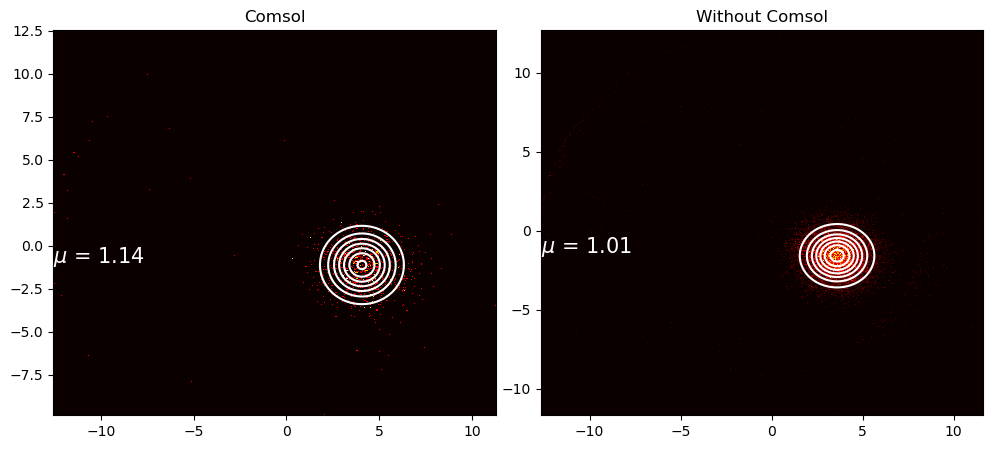

In [23]:
f,ax=plt.subplots(1,2,figsize=(12,5))

Event=Cm["event_id"]
#EventMask=Event==EvntID
EventMask=Event==EvntID
CameraMask=Cm["name"][EventMask]==b'camWindow'
binsize=400
ax[0].set_title("Comsol")
G4XCm=Cm["x"][EventMask][CameraMask]
G4YCm=Cm["y"][EventMask][CameraMask]
#Event=Cm["Diffusion"]["Event"]
#EventMask=Event==EvntID
#MaxMax=Cm["Diffusion"]["dt"][EventMask]<np.max(Cm["Diffusion"]["dt"][EventMask])
#dt=Cm["Diffusion"]["dt"][EventMask][MaxMax]
if(len(G4XCm)>100):
    ComsolFit=FitSumsof_N_2DGaussian(G4XCm,G4YCm,ax[0],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)
    print(ComsolFit[1])
Event=NoCm["event_id"]
#EventMaskNoCM=Event==EvntID
EventMaskNoCM=Event==EvntID

CameraMaskNoCM=NoCm["name"][EventMaskNoCM]==b'camWindow'

ax[1].set_title("Without Comsol")
G4NoCmX=NoCm["x"][EventMaskNoCM][CameraMaskNoCM]
G4NoCmY=NoCm["y"][EventMaskNoCM][CameraMaskNoCM]
#Event=NoCm["Diffusion"]["Event"]
#EventMask=Event==EvntID
#MaxMax=_4cm_NoComsol["Diffusion"]["dt"][EventMask]<np.max(_4cm_NoComsol["Diffusion"]["dt"][EventMask])
#dt_NoComsol=NoCm["Diffusion"]["dt"][EventMask]
if(len(G4XCm)>100):
    No_ComsolFit=FitSumsof_N_2DGaussian(G4NoCmX,G4NoCmY,ax[1],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)
    print(No_ComsolFit[1])

plt.subplots_adjust(wspace=0.1, hspace=0.1)

#plt.figure(figsize=(15,15),dpi=300)
#plt.title("Dts")

#plt.hist(dt,label="Without Comsol")
#print(dt)

[array([1.22]), array([1.06]), array([1.14]), array([4.07]), array([-1.2])]
[array([1.03]), array([0.97]), array([1.]), array([3.57]), array([-1.62])]


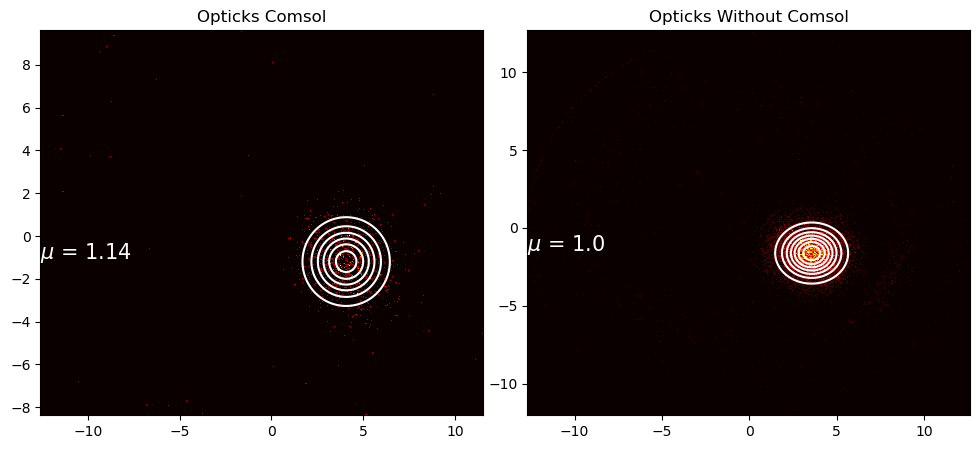

In [24]:
f,ax=plt.subplots(1,2,figsize=(12,5))
Event=O_Cm["event_id"]
EventMask=Event==EvntID
CameraMask=O_Cm["z"][EventMask]>100
binsize=400
ax[0].set_title("Opticks Comsol")
OXCm=O_Cm["x"][EventMask][CameraMask]
OYCm=O_Cm["y"][EventMask][CameraMask]
#Event=Cm["Diffusion"]["Event"]
#EventMask=Event==EvntID
#MaxMax=Cm["Diffusion"]["dt"][EventMask]<np.max(Cm["Diffusion"]["dt"][EventMask])
#dt=Cm["Diffusion"]["dt"][EventMask][MaxMax]

ComsolFit=FitSumsof_N_2DGaussian(OXCm,OYCm,ax[0],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)
print(ComsolFit[1])
Event=O_NoCm["event_id"]
EventMaskNoCM=Event==EvntID
CameraMaskNoCM=O_NoCm["z"][EventMaskNoCM]>100

ax[1].set_title("Opticks Without Comsol")
ONoCmX=O_NoCm["x"][EventMaskNoCM][CameraMaskNoCM]
ONoCmY=O_NoCm["y"][EventMaskNoCM][CameraMaskNoCM]
#Event=NoCm["Diffusion"]["Event"]
#EventMask=Event==EvntID
#MaxMax=_4cm_NoComsol["Diffusion"]["dt"][EventMask]<np.max(_4cm_NoComsol["Diffusion"]["dt"][EventMask])
#dt_NoComsol=NoCm["Diffusion"]["dt"][EventMask]
No_ComsolFit=FitSumsof_N_2DGaussian(ONoCmX,ONoCmY,ax[1],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)
print(No_ComsolFit[1])

plt.subplots_adjust(wspace=0.1, hspace=0.1)

#plt.figure(figsize=(15,15),dpi=300)
#plt.title("Dts")

#plt.hist(dt,label="Without Comsol")
#print(dt)

[array([4.82]), array([4.7]), array([4.76]), array([-17.8]), array([4.96])]


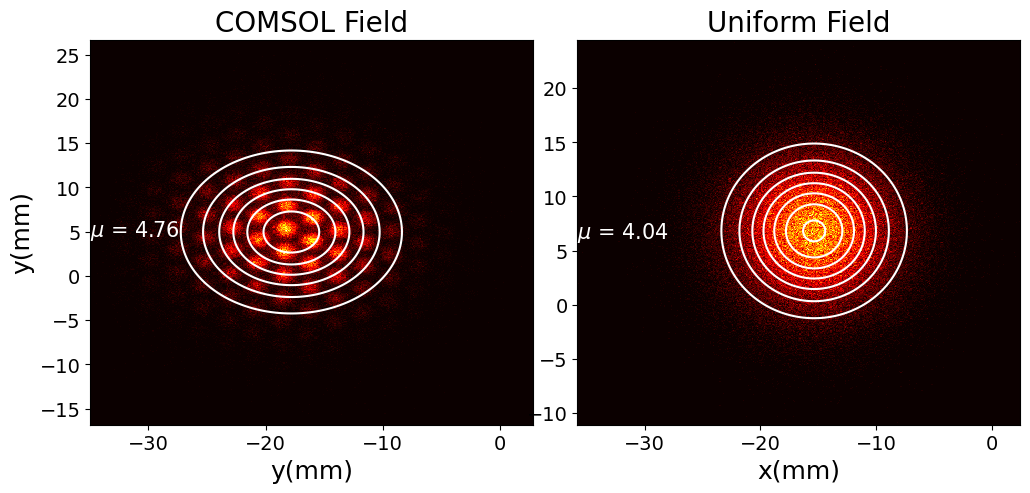

In [25]:
f,ax=plt.subplots(1,2,figsize=(12,5))
Event=ELWithComsol["event_id"]
EventMask=Event==EvntID
binsize=400
ax[0].set_title("COMSOL Field",fontsize=20)
ELXCm=ELWithComsol["x"][EventMask]*10
ELYCm=ELWithComsol["y"][EventMask]*10
#Event=Cm["Diffusion"]["Event"]
#EventMask=Event==EvntID
#MaxMax=Cm["Diffusion"]["dt"][EventMask]<np.max(Cm["Diffusion"]["dt"][EventMask])
#dt=Cm["Diffusion"]["dt"][EventMask][MaxMax]

ComsolFit=FitSumsof_N_2DGaussian(ELXCm,ELYCm,ax[0],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)
print(ComsolFit[1])
Event=ELNoComsol["event_id"]
EventMaskNoCM=Event==EvntID
CameraMaskNoCM=ELNoComsol["z"][EventMaskNoCM]>100

ax[1].set_title("Uniform Field",fontsize=20)
ELNoCmX=ELNoComsol["x"][EventMaskNoCM]*10
ELNoCmY=ELNoComsol["y"][EventMaskNoCM]*10
#Event=NoCm["Diffusion"]["Event"]
#EventMask=Event==EvntID
#MaxMax=_4cm_NoComsol["Diffusion"]["dt"][EventMask]<np.max(_4cm_NoComsol["Diffusion"]["dt"][EventMask])
#dt_NoComsol=NoCm["Diffusion"]["dt"][EventMask]
No_ComsolFit=FitSumsof_N_2DGaussian(ELNoCmX,ELNoCmY,ax[1],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
ax[1].set_xlabel("x(mm)",fontsize=18)
ax[0].set_ylabel("y(mm)",fontsize=18)
ax[0].set_xlabel("y(mm)",fontsize=18)
#plt.figure(figsize=(15,15),dpi=300)
#plt.title("Dts")
ax[0].tick_params(axis='both', labelsize=14)
ax[1].tick_params(axis='both', labelsize=14)
#plt.hist(dt,label="Without Comsol")
#print(dt)

In [ ]:
ELNoCmX

In [ ]:

f,ax=plt.subplots(3,2,figsize=(12,12))
_=ax[0,0].hist2d(ELWithComsol["x"][EventMask]*10,ELWithComsol["y"][EventMask]*10,bins=400)
_=ax[0,1].hist2d(ELNoComsol["x"][EventMaskNoCM]*10,ELNoComsol["y"][EventMaskNoCM]*10,bins=400)
_=ax[1,1].hist2d(ONoCmX,ONoCmY,bins=400)
_=ax[2,0].hist2d(OXCm,OYCm,bins=400)
_=ax[2,1].hist2d(ONoCmX,ONoCmY,bins=400)
_=ax[1,0].hist2d(G4XCm,G4YCm,bins=400)
_=ax[1,1].hist2d(G4NoCmX,G4NoCmY,bins=400)
plt.xlim(-10,10)
plt.ylim(-10,10)

In [ ]:
f,ax=plt.subplots(2,2,figsize=(15,8))
#Event=Cm["Camera"]["Event"]
#EventMask=Event==EvntID

X=G4XCm
Y=G4YCm
print(X)
## First Hist
ax[0,0].set_title("Comsol X")

sample=np.random.normal(np.mean(X)-100,0.2,100)
testconvolve=np.convolve(sample,X,mode="same")
#print(sample)
FitSumsof_N_1DGaussian(X,ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)
#FitSumsof_N_1DGaussian(testconvolve,ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)
#plt.hist(testconvolve,bins=1000)
#FitSumsof_N_1DGaussian(testconvolve.flatten(),ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)

#ax[0,0].set_xlim(-5,1)
## Second Hist
FitSumsof_N_1DGaussian(Y,ax[0,1],NGaussians=1)

########################################
#Event=NoCm["Camera"]["Event"]
#EventMask=Event==EvntID

ax[1,0].set_title("Without Comsol X")
X=G4NoCmX
Y=G4NoCmY
ax[1,1].set_title("Without Comsol Y")

### Third Hist
FitSumsof_N_1DGaussian(X,ax[1,0],NGaussians=1,isPlot=True)

### Fourth Hist
FitSumsof_N_1DGaussian(Y,ax[1,1],NGaussians=1,isPlot=True)

plt.subplots_adjust(wspace=0.2, hspace=0.3)

In [ ]:
f,ax=plt.subplots(2,2,figsize=(15,8))
#Event=Cm["Camera"]["Event"]
#EventMask=Event==EvntID

X=OXCm
Y=OYCm
print(X)
## First Hist
ax[0,0].set_title("Comsol X")

sample=np.random.normal(np.mean(X)-100,0.2,100)
testconvolve=np.convolve(sample,X,mode="same")
#print(sample)
FitSumsof_N_1DGaussian(X,ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)
#FitSumsof_N_1DGaussian(testconvolve,ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)
#plt.hist(testconvolve,bins=1000)
#FitSumsof_N_1DGaussian(testconvolve.flatten(),ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)

#ax[0,0].set_xlim(-5,1)
## Second Hist
FitSumsof_N_1DGaussian(Y,ax[0,1],NGaussians=1)

########################################
#Event=NoCm["Camera"]["Event"]
#EventMask=Event==EvntID

ax[1,0].set_title("Without Comsol X")
X=ONoCmX
Y=ONoCmY
ax[1,1].set_title("Without Comsol Y")

### Third Hist
FitSumsof_N_1DGaussian(X,ax[1,0],NGaussians=1,isPlot=True)

### Fourth Hist
FitSumsof_N_1DGaussian(Y,ax[1,1],NGaussians=1,isPlot=True)

plt.subplots_adjust(wspace=0.2, hspace=0.3)

In [ ]:
f,ax=plt.subplots(2,2,figsize=(12,5))
Event=Cm["EL"]["Event"]
EventMask=Event==EvntID
binsize=300

X=Cm["EL"]["X"][EventMask]
Y=Cm["EL"]["Y"][EventMask]

#correlation = np.corrcoef(X,Y,ddof=12)[0, 1]
#print(f"Correlation {round(correlation,3)}")
### First Hist
ax[0,0].set_title("EL Comsol X")

Fit1=FitSumsof_N_1DGaussian(X,ax[0,0],NGaussians=1,isPlot=True,isPlotGM=True)

## Second Hist
ax[0,1].set_title("Comsol Y")

FitSumsof_N_1DGaussian(Y,ax[0,1],NGaussians=1,isPlot=True)


Event=NoCm["EL"]["Event"]
EventMask=Event==EvntID

ax[1,0].set_title("Without Comsol X")
X=NoCm["EL"]["X"][EventMask]
Y=NoCm["EL"]["Y"][EventMask]
ax[1,0].set_title("Without Comsol X")

#### Third Hist
FitSumsof_N_1DGaussian(X,ax[1,0],NGaussians=1,isPlot=True)

#FitSumsof_N_1DGaussian(X-5,ax[0,0],NGaussians=1,isPlot=True)
#samples = np.random.normal(loc=-1.85e1, scale=4.719, size=10000)
#weight=np.ones_like(samples)*40
#ax[0,0].hist(samples,weights=weight,bins=200,color="yellow")
#### Fourth Hist
FitSumsof_N_1DGaussian(Y,ax[1,1],NGaussians=1,isPlot=True)
#FitSumsof_N_1DGaussian(Y,ax[0,1],NGaussians=1,isPlot=True)
plt.subplots_adjust(wspace=0.2, hspace=0.3)

In [ ]:
print(np.sqrt(np.sum(Fit1[1]**2)))

In [ ]:
Fit1[1]

In [ ]:
f,ax=plt.subplots(1,2,figsize=(12,5))
Event=Cm["EL"]["Event"]
EventMask=Event==EvntID
binsize=300
ax[0].set_title("EL Comsol")
X=Cm["EL"]["X"][EventMask]
Y=Cm["EL"]["Y"][EventMask]
EL_Comsol=FitSumsof_N_2DGaussian(X,Y,ax[0],NGaussians=1,isPlot=True,isPrint=True,binsize=binsize)



Event=NoCm["EL"]["Event"]
EventMask=Event==EvntID

ax[1].set_title("EL Without Comsol")
X=NoCm["EL"]["X"][EventMask]
Y=NoCm["EL"]["Y"][EventMask]
EL_NoComsol=FitSumsof_N_2DGaussian(X,Y,ax[1],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [ ]:
## To excract the correction factor
def CreateDistribution(comsol,Nocomsol,key=["EL","X","Y","Z"],bins=[50,50],isPlot=[True,False]):
    Limit=100
    SigmasX_=np.array([])
    SigmasY_=np.array([])
    MeanSigmas_=np.array([])
    MeanX_=np.array([])
    MeanY_=np.array([])
    Event=comsol[key[0]]["Event"]
    UniqueOnes=np.unique(Event)
    print(f"Running Comsol Events {len(UniqueOnes)} ...")
    Count_1=0
    for Evt in UniqueOnes:
        EventMask=Event==Evt
        #print(f"Event {Evt}")
        X=comsol[key[0]][key[1]][EventMask]
        Y=comsol[key[0]][key[2]][EventMask]
        if(len(X)<Limit):
            Count_1=Count_1+1
            continue
        #print(f"Event {Evt} lengths X is {len(X)} Y is {len(Y)}")
        fitresult=FitSumsof_N_2DGaussian(X,Y,None,NGaussians=1,isPlot=isPlot[1],isPrint=False,binsize=bins[0])
        SigmasX_=np.append(SigmasX_,fitresult[1][0])
        SigmasY_=np.append(SigmasY_,fitresult[1][1])
        MeanSigmas_=np.append(MeanSigmas_,fitresult[1][2])
        MeanX_=np.append(MeanX_,fitresult[1][3])
        MeanY_=np.append(MeanY_,fitresult[1][4])

    
   
    Event=Nocomsol[key[0]]["Event"]
    _SigmasX=np.array([])
    _SigmasY=np.array([])
    _MeanSigmas=np.array([])
    _MeanX=np.array([])
    _MeanY=np.array([])
    UniqueOnes=np.unique(Event)
    
    print(f"Running Uniform Field Events {len(UniqueOnes)} ...")
    
    Count_2=0
    for Evt in UniqueOnes:
        EventMask=Event==Evt
        #print(f"Event {Evt}")
        X=Nocomsol[key[0]][key[1]][EventMask]
        Y=Nocomsol[key[0]][key[2]][EventMask]
        if(len(X)<Limit):
            Count_2=Count_2+1
            continue
        fitresult=FitSumsof_N_2DGaussian(X,Y,None,NGaussians=1,isPlot=isPlot[1],isPrint=False,binsize=bins[0])
        _SigmasX=np.append(_SigmasX,fitresult[1][0])
        _SigmasY=np.append(_SigmasY,fitresult[1][1])
        _MeanSigmas=np.append(_MeanSigmas,fitresult[1][2])
        _MeanX=np.append(_MeanX,fitresult[1][3])
        _MeanY=np.append(_MeanY,fitresult[1][4])
        
    
    '''if(Count_1!=Count_2):
        CountMin=np.max([Count_1,Count_2])
        if(Count_1==CountMin):
            _SigmasX=_SigmasX[:-CountMin]
            _SigmasY=_SigmasY[:-CountMin]
            _MeanSigmas=_MeanSigmas[:-CountMin]
        elif(Count_2==CountMin):
            SigmasX_=SigmasX_[:-CountMin]
            SigmasY_=SigmasY_[:-CountMin]
            MeanSigmas_=MeanSigmas_[:-CountMin] 
    '''
    
    
    
    SigXMin=np.min([np.min(SigmasX_),np.min(_SigmasX)])
    SigYMin=np.min([np.min(SigmasY_),np.min(_SigmasY)])
    MeanSigMin=np.min([np.min(MeanSigmas_),np.min(_MeanSigmas)])
    SigXMax=np.max([np.max(SigmasX_),np.max(_SigmasX)])
    SigYMax=np.max([np.max(SigmasY_),np.max(_SigmasY)])
    MeanSigMax=np.max([np.max(MeanSigmas_),np.max(_MeanSigmas)])
   
    
    SigXBins=np.linspace(SigXMin,SigXMax,bins[1])
    SigYBins=np.linspace(SigYMin,SigYMax,bins[1])
    MeanSigBins=np.linspace(MeanSigMin,MeanSigMax,bins[1])
    
    
    factorX=np.mean(_SigmasX)/np.mean(SigmasX_)
    factorY=np.mean(_SigmasY)/np.mean(SigmasY_)
    factorMean=np.mean(_MeanSigmas)/np.mean(MeanSigmas_)
 
    if(isPlot[0]):    
        f,ax=plt.subplots(2,3,figsize=(12,5))
        ax[0,0].set_title("Comsol X")
        rx1=ax[0,0].hist(SigmasX_,bins=SigXBins)
        ax[0,1].set_title("Y")
        ry1=ax[0,1].hist(SigmasY_,bins=SigYBins)
        ax[0,2].set_title("Mean")
        rm1=ax[0,2].hist(MeanSigmas_,bins=MeanSigBins)    
        rx2=ax[1,0].hist(_SigmasX,bins=SigXBins)
        ry2=ax[1,1].hist(_SigmasY,bins=SigYBins)    
        rm2=ax[1,2].hist(_MeanSigmas,bins=MeanSigBins)
        #ax[2,0].hist(factorXs,bins=bins[1])
        #ax[2,1].hist(factorYs,bins=bins[1])    
        #ax[2,2].hist(factorMeans,bins=bins[1])
    
    
    print(f" FactorX {round(factorX,2)} FactorY {round(factorY,2)} FactorMean {round(factorMean,2)}")
    All={"Factors":[factorX,factorY,factorMean],
         "ComsolSigmas":[SigmasX_,SigmasY_,MeanSigmas_],
         "Sigmas":[_SigmasX,_SigmasY,_MeanSigmas],
         "ComsolMeans":[MeanX_,MeanY_],
         "Means":[_MeanX,_MeanY]}
    return All
    

In [ ]:
_Res4cm=CreateDistribution(_4cm,_4cm_NoComsol,isPlot=[True,False],bins=[300,30])

In [ ]:
_Res9cm=CreateDistribution(_9cm,_9cm_NoComsol,isPlot=[True,False],bins=[100,30])

In [ ]:
_Res9cm=CreateDistribution(_14cm,_14cm_NoComsol,isPlot=[True,False])